• A zip folder named media_lab_data.zip containing:

• students.json – Student data with names and grades.

• attendance.csv – Attendance records.

• college_info.xlsx – General college info.

• sample.html – A saved HTML page with event announcements.

• student_photo.jpg – A scanned student photo.

• greeting_audio.wav – A greeting audio file.

• event_clip.mp4 – A short event recording.

1. Text/Tabular Data

• Load all three files (students.json, attendance.csv, and college_info.xlsx) using
Pandas.

• Merge student grades and attendance based on a common key (like Student ID).

• Clean column names (lowercase, remove spaces).

• Export the merged file as a new CSV.

2. Web Scraping

• Using BeautifulSoup, extract all <h2> and <p> tags from sample.html.

• Display them in a readable format.

3. Image

• Load the student_photo.jpg using PIL or OpenCV.

• Convert it to grayscale and resize it to 100x100 pixels.

4. Video

• Load event_clip.mp4 using OpenCV.

• Extract the first frame and save it as first_frame.jpg.

In [25]:
import pandas as pd
import json
import os
import zipfile
import numpy as np
import cv2
from scipy.io import wavfile

if os.path.exists('/content'):
    os.chdir('/content')

# 1. Create a directory for the files
folder_name = "media_lab_files"
os.makedirs(folder_name, exist_ok=True)

# 2. students.json - Enhanced with more students and grades [cite: 118]
students = [
    {"name": "Alice Smith", "roll_no": "2024001", "grade": "A+", "dept": "Computer Science", "email": "alice.smith@college.edu"},
    {"name": "Bob Johnson", "roll_no": "2024002", "grade": "A", "dept": "Electronics", "email": "bob.johnson@college.edu"},
    {"name": "Carol Williams", "roll_no": "2024003", "grade": "B+", "dept": "Mechanical", "email": "carol.w@college.edu"},
    {"name": "David Brown", "roll_no": "2024004", "grade": "A-", "dept": "Computer Science", "email": "d.brown@college.edu"}
]
with open(f"{folder_name}/students.json", "w") as f:
    json.dump(students, f, indent=4)

# 3. attendance.csv - Structured attendance records [cite: 123]
attendance_data = {
    'Date': ['2024-03-01', '2024-03-01', '2024-03-01', '2024-03-02', '2024-03-02'],
    'Student': ['Alice', 'Bob', 'Carol', 'Alice', 'Bob'],
    'Status': ['Present', 'Present', 'Present', 'Present', 'Absent']
}
pd.DataFrame(attendance_data).to_csv(f"{folder_name}/attendance.csv", index=False)

# 4. college_info.xlsx - General info [cite: 137]
college_info = {
    'Department': ['CS', 'Electronics', 'Mechanical', 'Civil'],
    'HOD': ['Dr. Aris', 'Dr. Khanna', 'Dr. Singh', 'Dr. Verma'],
    'Labs': [12, 8, 10, 5]
}
pd.DataFrame(college_info).to_excel(f"{folder_name}/college_info.xlsx", index=False)

# 5. sample.html - HTML with events and a results table [cite: 28, 133]
html_content = """
<html>
<head><title>ABC College Portal</title></head>
<body>
    <h1>Welcome to ABC College</h1>
    <div class="events">
        <h2>Upcoming Events</h2>
        <div class="event">
            <h3>Annual Tech Fest 2024</h3>
            <p class="date">March 15-17, 2024</p>
            <p class="venue">Main Auditorium</p>
            <p class="description">A celebration of innovation and technology.</p>
            <a href="/register/techfest">Register Here</a>
        </div>
        <div class="event">
            <h3>Sports Day</h3>
            <p class="date">March 25, 2024</p>
            <p class="venue">Sports Complex</p>
            <p class="description">Inter-departmental athletic competitions.</p>
            <a href="/register/sports">Register Here</a>
        </div>
    </div>
    <table class="results">
        <tr><th>Roll No</th><th>Name</th><th>Math</th><th>Science</th></tr>
        <tr><td>101</td><td>Alice</td><td>95</td><td>90</td></tr>
        <tr><td>102</td><td>Bob</td><td>88</td><td>85</td></tr>
    </table>
</body>
</html>
"""
with open(f"{folder_name}/sample.html", "w") as f:
    f.write(html_content)

# 6. student_photo.jpg - Dummy image [cite: 40, 230]
dummy_img = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.rectangle(dummy_img, (50, 50), (250, 250), (255, 255, 255), -1)
cv2.putText(dummy_img, 'ID PHOTO', (80, 160), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
cv2.imwrite(f"{folder_name}/student_photo.jpg", dummy_img)

# 7. greeting_audio.wav - Dummy audio [cite: 1]
samplerate = 44100
t = np.linspace(0, 1, samplerate)
data = np.sin(2 * np.pi * 440 * t)
wavfile.write(f"{folder_name}/greeting_audio.wav", samplerate, (data * 32767).astype(np.int16))

# 8. event_clip.mp4 - Dummy video [cite: 232]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(f"{folder_name}/event_clip.mp4", fourcc, 10.0, (640, 480))
for i in range(30):
    frame = np.zeros((480, 640, 3), dtype=np.uint8)
    cv2.putText(frame, f'Frame {i}', (200, 240), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
    out.write(frame)
out.release()

# 9. ZIP everything together
with zipfile.ZipFile('media_lab_data.zip', 'w') as zipf:
    for root, dirs, files in os.walk(folder_name):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=file)

print("✓ media_lab_data.zip has been generated with enhanced sample data!")

✓ media_lab_data.zip has been generated with enhanced sample data!


1. Preparation: Unzip the Data

First, run this cell to extract your files so the scripts can find them.

In [26]:
import zipfile
import os

# Unzip the uploaded file
with zipfile.ZipFile('media_lab_data.zip', 'r') as zip_ref:
    zip_ref.extractall('media_lab_data')

# Change directory to the extracted folder
os.chdir('media_lab_data')
print("Files extracted:", os.listdir())

Files extracted: ['attendance.csv', 'sample.html', 'college_info.xlsx', 'student_photo.jpg', 'students.json', 'event_clip.mp4', 'greeting_audio.wav']


2. Web Scraping Practice

Task: Extract all <h2> and <p> tags from sample.html and display them.

In [27]:
from bs4 import BeautifulSoup

# Load the local HTML file
with open('sample.html', 'r', encoding='utf-8') as file:
    html_content = file.read()

# Parse the HTML
soup = BeautifulSoup(html_content, 'lxml')

print("--- H2 Headings ---")
for h2 in soup.find_all('h2'):
    print(f"• {h2.text.strip()}")

print("\n--- Paragraphs ---")
for p in soup.find_all('p'):
    print(f"- {p.text.strip()}")

--- H2 Headings ---
• Upcoming Events

--- Paragraphs ---
- March 15-17, 2024
- Main Auditorium
- A celebration of innovation and technology.
- March 25, 2024
- Sports Complex
- Inter-departmental athletic competitions.


3. Image Manipulation Practice

Task: Load student_photo.jpg, convert to grayscale, and resize to 100x100 pixels.

Image processed and saved as 'processed_student.jpg'


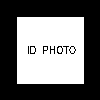

In [28]:
import cv2
from google.colab.patches import cv2_imshow # Special import for Colab

# Load the image using OpenCV [cite: 230]
image = cv2.imread('student_photo.jpg')

# Convert to grayscale [cite: 231]
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Resize to 100x100 [cite: 231]
resized_image = cv2.resize(gray_image, (100, 100))

# Save the result
cv2.imwrite('processed_student.jpg', resized_image)
print("Image processed and saved as 'processed_student.jpg'")

# Display results in Colab
cv2_imshow(resized_image)

4. Video Manipulation Practice

Task: Load event_clip.mp4, extract the first frame, and save it.

In [29]:
import cv2

# Load the video file [cite: 232]
video = cv2.VideoCapture('event_clip.mp4')

# Read the first frame [cite: 233]
success, frame = video.read()

if success:
    # Save the first frame as a JPG [cite: 233]
    cv2.imwrite('first_frame.jpg', frame)
    print("✓ Successfully saved 'first_frame.jpg'")
else:
    print("✗ Could not read the video file.")

video.release()

✓ Successfully saved 'first_frame.jpg'


5. Loading Structured Data (JSON, CSV, Excel)

Task: Use Pandas to organize the scraped/loaded data into tables.

In [30]:
import pandas as pd

# 1. Load CSV (Attendance)
attendance_df = pd.read_csv('attendance.csv')
print("\n--- Attendance Records ---")
display(attendance_df.head())

# 2. Load JSON (Students)
students_df = pd.read_json('students.json')
print("\n--- Student Grades ---")
display(students_df.head())

# 3. Load Excel (College Info)
# Note: You may need to install 'openpyxl' in Colab: !pip install openpyxl
college_df = pd.read_excel('college_info.xlsx')
print("\n--- College Information ---")
display(college_df.head())


--- Attendance Records ---


,Date,Student,Status
0,2024-03-01,Alice,Present
1,2024-03-01,Bob,Present
2,2024-03-01,Carol,Present
3,2024-03-02,Alice,Present
4,2024-03-02,Bob,Absent



--- Student Grades ---


,name,roll_no,grade,dept,email
0,Alice Smith,2024001,A+,Computer Science,alice.smith@college.edu
1,Bob Johnson,2024002,A,Electronics,bob.johnson@college.edu
2,Carol Williams,2024003,B+,Mechanical,carol.w@college.edu
3,David Brown,2024004,A-,Computer Science,d.brown@college.edu



--- College Information ---


,Department,HOD,Labs
0,CS,Dr. Aris,12
1,Electronics,Dr. Khanna,8
2,Mechanical,Dr. Singh,10
3,Civil,Dr. Verma,5


6. Audio Handling (Bonus)

Since your zip includes greeting_audio.wav, here is how to play it directly inside your Colab notebook:

In [31]:
import IPython.display as ipd

# Play the audio file
ipd.Audio('greeting_audio.wav')